# Computational Physics Lab: Brief overview of computational physics

## Learning objectives

By the end of this lab you will be able to:

1. Translate a simple differential equation into a numerical algorithm.
2. Implement the forward Euler method and compare it with an exact solution.
3. Quantify numerical error and check a physical invariant (energy).
4. Use Git to record successive improvements to a computational project.
5. Produce a short, evidence-based conclusion about accuracy and time-step choice.

## How to use this notebook

- **Markdown cells** (this one) contain explanations and instructions.
- **Code cells** contain executable Python. Click a cell and press `Shift+Enter` to run it.
- Output appears immediately below the cell.
- Always run cells **in order** from top to bottom the first time through.
- When you change a parameter, re-run the cell (and any later cells that depend on it).
## More information
- [Numerical Physics class](https://github.com/Physics-is-awesome/Intro_comp_phys/tree/For_NEP), make sure to use For_NEP Branch
- [What to install](https://liveutk-my.sharepoint.com/:w:/g/personal/acason4_vols_utk_edu/IQC37wBt2kRdQ4WLLkeHE_c5Ad5ljTxksYmIdk3wi7mf7RI?e=gzC1UB)
- [Mini projects](https://liveutk-my.sharepoint.com/:w:/r/personal/acason4_vols_utk_edu/Documents/Readings%20and%20mini-projects.docx?d=w4246d0298dc4406e85f8964c413fa240&csf=1&web=1&e=YigMMJ)
---

## 0. Introduction and setup and Github 

Import the libraries we need and confirm that the environment is working.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: SciPy will be used later for a high-accuracy reference
from scipy.integrate import solve_ivp

print("NumPy version:", np.__version__)
print("Ready.")

NumPy version: 2.4.6
Ready.



---


This notebook is intended to live inside a small project repository:

```
tutorial/
├── oscillator_lab.ipynb 
├── finite_diference_cfd.ipynb 
└── MHD.ipnb
```

### Suggested Git workflow (run these in a terminal, not inside the notebook, VS code has alternatives to this Terminal use that you can use instead)

```bash
# Clone
git clone https://github.com/mykirby/SSTA-NEP.git    # clone repository
git pull                                             # get updates
# Creating your Own Branch
git switch -c name_of_branch    # you can name it what ever you want, this is your branch for now.
git branch                      # confirm you are on the branch you think, should see "* name_of branch" with a list underneath


# Push to branch
git branch                      # Confirm you are in the right branch
git add .                       # "." adds all modified or added files that aren't spesifically told not to be added according to .gitignore
git add oscillator_lab.ipynb   # add spesific file(s)
git commit -m "Add forward Euler integrator and comparison with exact solution"    # commit with comment about it
git push                       # push to branch

# Git pull, if we update the main repository
git switch main
git pull origin main                               # get updates
git switch name_of_branch                          # return to your branch
git merge main                                     # get updates on your branch
git rebase main                                    # alternative to merge

git fetch origin                                   #shorter version
git merge origin/main
```

Before each commit:

```bash
git status          # tells you what files have been changed, what files are staged, how many commits ahead/behind of main, etc
git diff            # tells you exactly what has been changed
```

**Note:** Jupyter notebooks store both code and output. Diffs can be noisy. A practical habit is to restart the kernel, "Run All", and save before the final commit of a session.

Record in the commit message (or a short `notes.md`):

- the time step(s) you used,
- which integrator,
- any parameter changes,
- a one-line observation about accuracy or energy.

---

### First plot — a pure analytic oscillator

The exact solution of the undamped harmonic oscillator with amplitude $A$ and angular frequency $\omega$ is

$$x(t) = A\cos(\omega t)$$

(assuming the initial velocity is zero).


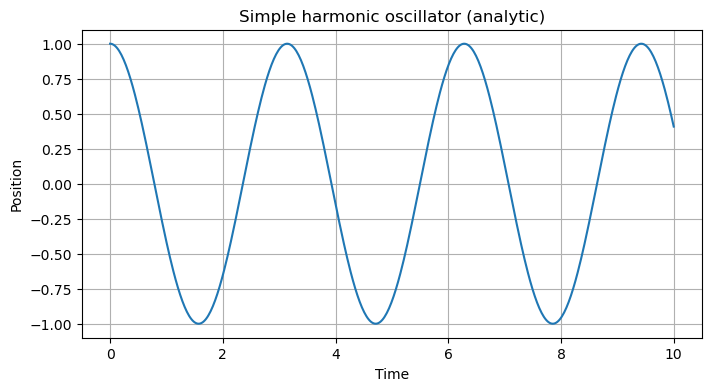

In [2]:
A = 1.0      # amplitude
omega = 2.0  # angular frequency (rad / unit time)
t = np.linspace(0, 10, 500)

x_exact = A * np.cos(omega * t)

plt.figure(figsize=(8, 4))
plt.plot(t, x_exact)
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Simple harmonic oscillator (analytic)")
plt.grid(True)
plt.show()



---

## 1. Python essentials for scientific computing 
We will need variables, functions, NumPy arrays, and vectorized operations. The short examples below refresh the essentials.

In [3]:
# Variables and arithmetic
x0 = 1.0          # initial position
v0 = 0.0          # initial velocity
dt = 0.05         # time step
t_end = 10.0      # final time
omega = 2.0       # keep units consistent: omega has units of 1/time

print(f"Number of steps ≈ {int(t_end / dt)}")

Number of steps ≈ 200


In [4]:
# NumPy arrays and vectorized operations
t_demo = np.arange(0, 1.0, 0.25)
print("t_demo =", t_demo)
print("t_demo**2 =", t_demo**2)   # element-wise, no explicit loop needed

t_demo = [0.   0.25 0.5  0.75]
t_demo**2 = [0.     0.0625 0.25   0.5625]


In [5]:
# A simple Python function
def period(omega):
    """Return the oscillation period for angular frequency omega."""
    return 2 * np.pi / omega

print(f"Period for omega = {omega}: {period(omega):.4f}")

Period for omega = 2.0: 3.1416




---

## 2. From physics to equations 

The undamped harmonic oscillator obeys the first-order system

$$
\dot{x} = v, \qquad \dot{v} = a = -\omega^2 x.
$$

State vector: $(x, v)$.  
Initial conditions we will use throughout: $x(0) = 1$, $v(0) = 0$, $\omega = 2$.

The exact solution for these data is

$$
x(t) = \cos(\omega t), \qquad v(t) = -\omega\sin(\omega t).
$$

A numerical method turns the differential equations into an **algorithm** that advances the state by a finite time step $\Delta t$.

In [6]:
# Canonical parameters for the rest of the notebook
x0 = 1.0
v0 = 0.0
omega = 2.0
t_end = 10.0

def exact_solution(t, omega=omega):
    """Analytic position and velocity for x(0)=1, v(0)=0."""
    x = np.cos(omega * t)
    v = -omega * np.sin(omega * t)
    return x, v

# Quick sanity check
t_test = np.array([0.0, np.pi / omega])
x_test, v_test = exact_solution(t_test)
print("x at t=0 and t=T/2:", x_test)
print("v at t=0 and t=T/2:", v_test)

x at t=0 and t=T/2: [ 1. -1.]
v at t=0 and t=T/2: [-0.0000000e+00 -2.4492936e-16]


---

## 3. Implement a numerical integrator 

### 3.1 Forward Euler

The forward Euler step is

$$
\begin{aligned}
x_{n+1} &= x_n + \Delta t\, v_n,\\
v_{n+1} &= v_n + \Delta t\,(-\omega^2 x_n) = v_n + a_n \Delta t.
\end{aligned}
$$

The derivatives are evaluated at the *old* state only.

In [7]:
def euler_oscillator(x0, v0, dt, t_end, omega):
    """Integrate the harmonic oscillator with forward Euler.

    Parameters
    ----------
    x0, v0 : float
        Initial position and velocity.
    dt : float
        Time step.
    t_end : float
        Final time.
    omega : float
        Angular frequency.

    Returns
    -------
    t, x, v : ndarray
        Time, position and velocity arrays.
    """
    n = int(round(t_end / dt))
    t = np.arange(n + 1) * dt

    x = np.zeros(n + 1)
    v = np.zeros(n + 1)

    x[0] = x0
    v[0] = v0

    for i in range(n):
        # Evaluate derivatives using the old state
        dx = v[i]
        dv = -omega**2 * x[i]

        # Advance the solution
        x[i + 1] = x[i] + dt * dx
        v[i + 1] = v[i] + dt * dv

    return t, x, v

Run Euler and compare with the exact solution.

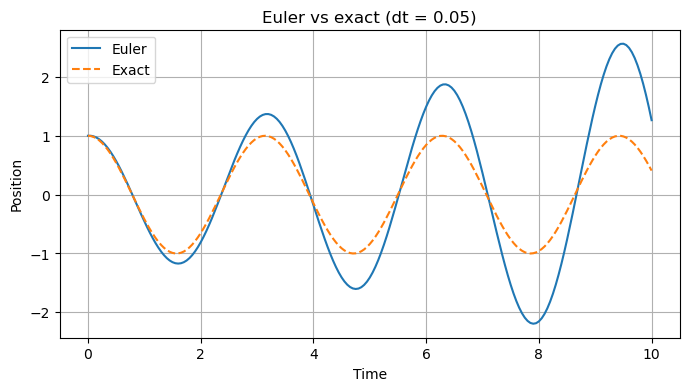

In [8]:
dt = 0.05
t, x, v = euler_oscillator(x0, v0, dt, t_end, omega)

x_exact, v_exact = exact_solution(t, omega)

plt.figure(figsize=(8, 4))
plt.plot(t, x, label="Euler")
plt.plot(t, x_exact, "--", label="Exact")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title(f"Euler vs exact (dt = {dt})")
plt.legend()
plt.grid(True)
plt.show()

**Task:** Identify where the numerical curve starts to depart from the exact curve. Does the error grow steadily? Does the numerical period look slightly wrong?

### 3.2 Classical Runge–Kutta (RK4)

RK4 evaluates the derivative four times per step and is fourth-order accurate. We supply a ready-made implementation so you can compare methods without writing another integrator from scratch. We won't focus on this too much right now but you can look into it.

In [19]:
def rk4_oscillator(x0, v0, dt, t_end, omega):
    """Integrate the harmonic oscillator with classical RK4."""
    n = int(round(t_end / dt))
    t = np.arange(n + 1) * dt
    x = np.zeros(n + 1)
    v = np.zeros(n + 1)
    x[0], v[0] = x0, v0

    def f(x, v):
        return v, -omega**2 * x

    for i in range(n):
        k1x, k1v = f(x[i], v[i])
        k2x, k2v = f(x[i] + 0.5*dt*k1x, v[i] + 0.5*dt*k1v)
        k3x, k3v = f(x[i] + 0.5*dt*k2x, v[i] + 0.5*dt*k2v)
        k4x, k4v = f(x[i] + dt*k3x, v[i] + dt*k3v)

        x[i+1] = x[i] + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
        v[i+1] = v[i] + (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)

    return t, x, v

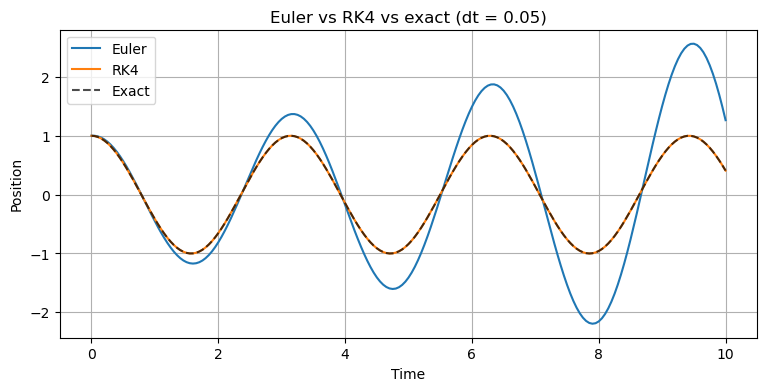

In [20]:
# Compare Euler and RK4 at the same time step
t_e, x_e, v_e = euler_oscillator(x0, v0, dt, t_end, omega)
t_r, x_r, v_r = rk4_oscillator(x0, v0, dt, t_end, omega)
x_ex, _ = exact_solution(t_e, omega)

plt.figure(figsize=(9, 4))
plt.plot(t_e, x_e, label="Euler")
plt.plot(t_r, x_r, label="RK4")
plt.plot(t_e, x_ex, "k--", label="Exact", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Position")
plt.title(f"Euler vs RK4 vs exact (dt = {dt})")
plt.legend()
plt.grid(True)
plt.show()

**Optional SciPy reference.** `solve_ivp` with a tight tolerance gives a high-accuracy benchmark.

In [21]:
def oscillator_ode(t, y, omega):
    x, v = y
    return [v, -omega**2 * x]

sol = solve_ivp(
    oscillator_ode, [0, t_end], [x0, v0],
    args=(omega,), dense_output=True, rtol=1e-10, atol=1e-10
)
t_ref = np.linspace(0, t_end, 500)
x_ref = sol.sol(t_ref)[0]

print("SciPy solve_ivp finished. Max |x_ref - exact| =",
      np.max(np.abs(x_ref - np.cos(omega * t_ref))))

SciPy solve_ivp finished. Max |x_ref - exact| = 6.258064066955171e-10


---

## 4. Numerical error and physical diagnostics 

Visual inspection is useful, but quantitative diagnostics are essential.

### 4.1 Absolute error versus time

Maximum absolute error (Euler): 1.5749900794419438


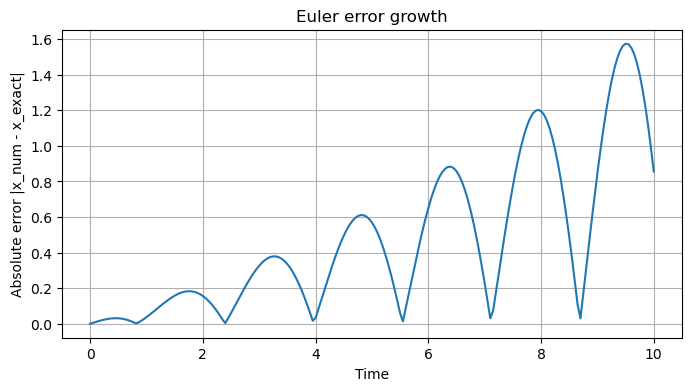

In [22]:
error_euler = np.abs(x_e - x_ex)

print("Maximum absolute error (Euler):", np.max(error_euler))

plt.figure(figsize=(8, 4))
plt.plot(t_e, error_euler)
plt.xlabel("Time")
plt.ylabel("Absolute error |x_num - x_exact|")
plt.title("Euler error growth")
plt.grid(True)
plt.show()

### 4.2 Convergence study

Run the same simulation with several time steps and record the maximum absolute error.

In [23]:
steps = [0.2, 0.1, 0.05, 0.025]
errors_euler = []
errors_rk4 = []

for dt_test in steps:
    t_t, x_t, _ = euler_oscillator(x0, v0, dt_test, t_end, omega)
    x_ex_t, _ = exact_solution(t_t, omega)
    errors_euler.append(np.max(np.abs(x_t - x_ex_t)))

    t_t, x_t, _ = rk4_oscillator(x0, v0, dt_test, t_end, omega)
    x_ex_t, _ = exact_solution(t_t, omega)
    errors_rk4.append(np.max(np.abs(x_t - x_ex_t)))

print(f"{'dt':>8}  {'Euler max err':>14}  {'RK4 max err':>14}")
print("-" * 40)
for dt_test, e_e, e_r in zip(steps, errors_euler, errors_rk4):
    print(f"{dt_test:8.4f}  {e_e:14.6e}  {e_r:14.6e}")

      dt   Euler max err     RK4 max err
----------------------------------------
  0.2000    3.983643e+01    3.746106e-03
  0.1000    5.598208e+00    2.317766e-04
  0.0500    1.574990e+00    1.459530e-05
  0.0250    6.043458e-01    9.324291e-07


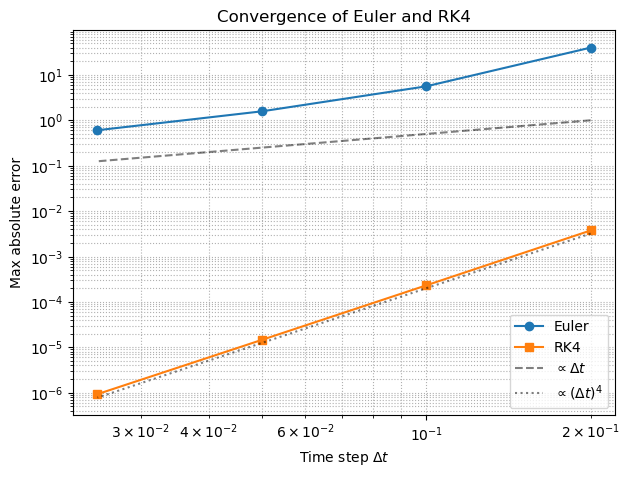

In [24]:
# Log-log plot of error vs time step (optional but informative)
plt.figure(figsize=(7, 5))
plt.loglog(steps, errors_euler, "o-", label="Euler")
plt.loglog(steps, errors_rk4, "s-", label="RK4")
# Reference slopes
dt_ref = np.array(steps)
plt.loglog(dt_ref, 5 * np.array(steps), "k--", alpha=0.5, label=r"$\propto \Delta t$")
plt.loglog(dt_ref, 2 * np.array(steps)**4, "k:", alpha=0.5, label=r"$\propto (\Delta t)^4$")
plt.xlabel(r"Time step $\Delta t$")
plt.ylabel("Max absolute error")
plt.title("Convergence of Euler and RK4")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

**Questions**

- Does reducing $\Delta t$ by a factor of two reduce the Euler error by roughly the same factor? (First-order method.)
- How does the RK4 error behave?

### 4.3 Energy diagnostic

For a unit-mass oscillator the total energy is

$$
E(t) = \frac12 v(t)^2 + \frac12 \omega^2 x(t)^2.
$$

The exact undamped oscillator conserves $E$. A numerical method need not.

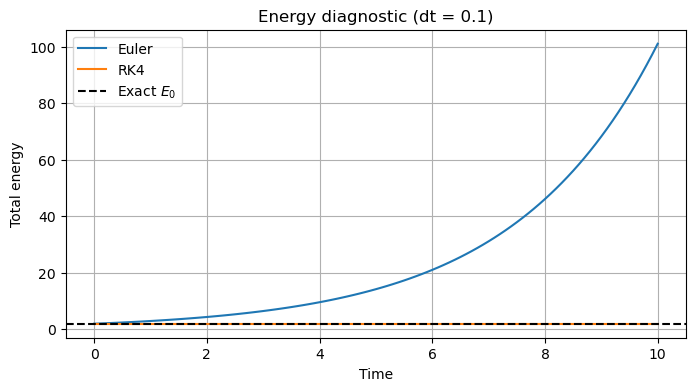

Initial energy E0 = 2.000000
Euler final energy = 101.009896  (drift = 9.900990e+01)
RK4   final energy = 1.999823  (drift = -1.768811e-04)


In [25]:
# Recompute with a moderately large step so the energy drift is visible
dt_energy = 0.1
t_en, x_en, v_en = euler_oscillator(x0, v0, dt_energy, t_end, omega)
_, x_rk, v_rk = rk4_oscillator(x0, v0, dt_energy, t_end, omega)

energy_euler = 0.5 * v_en**2 + 0.5 * omega**2 * x_en**2
energy_rk4   = 0.5 * v_rk**2  + 0.5 * omega**2 * x_rk**2
E0 = 0.5 * v0**2 + 0.5 * omega**2 * x0**2

plt.figure(figsize=(8, 4))
plt.plot(t_en, energy_euler, label="Euler")
plt.plot(t_en, energy_rk4, label="RK4")
plt.axhline(E0, color="k", ls="--", label="Exact $E_0$")
plt.xlabel("Time")
plt.ylabel("Total energy")
plt.title(f"Energy diagnostic (dt = {dt_energy})")
plt.legend()
plt.grid(True)
plt.show()

print(f"Initial energy E0 = {E0:.6f}")
print(f"Euler final energy = {energy_euler[-1]:.6f}  (drift = {energy_euler[-1]-E0:.6e})")
print(f"RK4   final energy = {energy_rk4[-1]:.6f}  (drift = {energy_rk4[-1]-E0:.6e})")


---

## Summary — what you should leave with

| Deliverable | Where it appears |
|-------------|------------------|
| Position plot (numeric vs exact) | Section 3 |
| Error / convergence comparison | Section 4 |
| Energy diagnostic | Section 4 |
| Short written conclusion | Section 6 |
| Commit history | Git (Section 5) |

You have walked through a complete computational-physics mini-project: model → algorithm → test → interpret → preserve.

## Further directions (optional)

- [Mini projects](https://liveutk-my.sharepoint.com/:w:/r/personal/acason4_vols_utk_edu/Documents/Readings%20and%20mini-projects.docx?d=w4246d0298dc4406e85f8964c413fa240&csf=1&web=1&e=YigMMJ)
- [Numerical Physics class](https://github.com/Physics-is-awesome/Intro_comp_phys/tree/For_NEP)
- finite_differences_cfd.ipynb
    - Brief introduction to finite difference
    - Brief computational fluid dynamics
    - Brief section on MHD that you can experiment with